In [15]:
# Importar o path do dataset da plataforma Kaggle
import kagglehub

# Importações essenciais do PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Importações do TorchVision para lidar com datasets de imagem
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset, DataLoader

#Para coletar as métricas do modelo e fazer a divisão do treino e teste
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# Para visualização (opcional, se quiser plotar gráficos depois)
import matplotlib.pyplot as plt
import pandas as pd

# Para a visualização da barra de progressão do treinamento
from tqdm.auto import tqdm

# Para conectar os paths das pastas do dataset
import os

# Configuração de dispositivo: Usa Placa de Vídeo (CUDA/MPS) se disponível, senão usa Processador (CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Dispositivo configurado: {device}")

Dispositivo configurado: cuda


In [16]:
# Fazer o download do dataset e pegar o path 
DATASET = kagglehub.dataset_download("utkarshps/skin-cancer-mnist10000-ham-augmented-dataset")
print("Path to dataset files:", DATASET)

Path to dataset files: /kaggle/input/datasets/utkarshps/skin-cancer-mnist10000-ham-augmented-dataset


In [17]:
# Carregando o path dos diretórios do treino e validação
IMAGE_TRAIN_PATH = DATASET + "/base_dir/train_dir"
IMAGE_VALID_PATH = DATASET + "/base_dir/val_dir"

# Pré-processamento das imagens do dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
     transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Carregar o dataset com estrutura de pastas com o ImageFolder
datasetTrainComplete  = torchvision.datasets.ImageFolder(root=f"{IMAGE_TRAIN_PATH}", transform=transform)
datasetValidation = torchvision.datasets.ImageFolder(root=f"{IMAGE_VALID_PATH}", transform=transform)

# Pegando as labels do dataset para pegar os indices das imagens
labels = [label for _, label in datasetTrainComplete.samples]
indices = list(range(len(labels)))

# Dividindo as imagens do treino para os testes, 
indices_train, indices_test = train_test_split(
    indices,
    test_size=0.15,       # Dessas imagens para o treino, 15% vai para teste e 85% fica para treino
    stratify=labels,      # Garante 15% de CADA classe, não do total, para não ocorrer o desbalanceamento
    random_state=42       # reprodutibilidade
)


# Cria os datasets de treino e teste
datasetTrain = Subset(datasetTrainComplete, indices_train)   # com augmentation
datasetTest  = Subset(datasetTrainComplete, indices_test)       # sem augmentation

print(len(datasetTrain))
print(len(datasetTest))
print(len(datasetValidation))

Exception ignored in: <function tqdm.__del__ at 0x788d636eba60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


32783
5786
938


In [18]:
from collections import Counter

# Função para verificar o balanceamento do dataset do Treino
def distribuicao(dataset, classes, nome):
    if hasattr(dataset, 'indices'):  # é um Subset (resultado do random_split)
        labels = [dataset.dataset.samples[i][1] for i in dataset.indices]
    else:
        labels = [label for _, label in dataset.samples]

    counter = Counter(labels)
    total = sum(counter.values())
    print(f"=== {nome} ===")
    for idx, qtd in sorted(counter.items()):
        print(f"{classes[idx]}: {qtd} ({qtd/total*100:.1f}%)")
    print()

distribuicao(datasetTrain, datasetTrainComplete.classes, "Treino")

=== Treino ===
akiec: 4434 (13.5%)
bcc: 4979 (15.2%)
bkl: 5032 (15.3%)
df: 3749 (11.4%)
mel: 5032 (15.3%)
nv: 5061 (15.4%)
vasc: 4496 (13.7%)



In [19]:
#Carregando os DataLoader de treino, validação e teste
trainLoader = DataLoader(datasetTrain, batch_size=200, shuffle=True, num_workers=4, persistent_workers=True)
validLoader = DataLoader(datasetValidation, batch_size=28, shuffle=False, num_workers=3, persistent_workers=True)
testLoader = DataLoader(datasetTest, batch_size=64, shuffle=False, num_workers=3, persistent_workers=True)

print("Tudo ok")

Tudo ok


In [20]:
class RedeCNN(nn.Module):
    def __init__(self):
        super(RedeCNN, self).__init__()

        # --- PARTE 1: Extrator de Características ---
        # nn.Sequential empacota as camadas, executando-as na ordem definida
        self.convolucoes = nn.Sequential(
            # Camada Conv 1: Entram os 3 canais e saem 32 novos filtros
            nn.Conv2d(in_channels=3 , out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Reduz a imagem pela metade (de 224x224 para 112x112)

            # Camada Conv 2: Entram os 32 canais anteriores, saem 64 novos filtros
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Reduz a imagem novamente (de 112x112 para 56x56)

            # Camada Conv 3: Entram os 64 canais anteriores, saem 128 novos filtros
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Reduz a imagem novamente (de 56x56 para 28x28)
            
            # Camada Conv 4: Entram os 128 canais anteriores, saem 256 novos filtros
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Reduz a imagem novamente (de 28x28 para 14x14)

            # Camada Conv 5: Entram os 64 canais anteriores, saem 128 novos filtros
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Reduz a imagem novamente (de 14x14 para 7x7)
        )

        # --- PARTE 2: Classificador ---
        self.classificador = nn.Sequential(
            nn.Flatten(), # Achata a imagem 2D em um vetor 1D

            # A imagem agora tem 512 canais de tamanho 7x7.
            nn.Linear(512 * 7 * 7, 150), # Camada oculta com 150 neurônios
            nn.ReLU(),
            nn.Dropout(0.3),            # "Desliga" 30% dos neurônios para evitar que a rede decore os dados (overfitting)
            nn.Linear(150, 7)          # Camada de saída: 7 neurônios caso for do tipo 'coarse', ou 81 se for 'fine'
        )

    def forward(self, x):
        # Fluxo de passagem dos dados pela rede
        x = self.convolucoes(x)
        x = self.classificador(x)
        return x

print("Tudo ok")

Tudo ok


In [21]:
#Criando o modelo da CNN e carregando na GPU ou CPU
modelo = RedeCNN().to(device)
print(modelo)

RedeCNN(
  (convolucoes): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classificador): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
 

In [22]:
#NESTA CÉLULA OCORRE O TREINAMENTO E VALIDAÇÃO DO MODELO

# Definindo Perda e Otimizador
criterio = nn.CrossEntropyLoss()
# lr=0.001 é a Taxa de Aprendizado (Learning Rate)
otimizador = optim.Adam(modelo.parameters(), lr=0.0002)

# Quantas vezes passaremos por todo o dataset de treino
epocas = 18

# Guardar as métricas do treino e do teste
historico = []

print("Iniciando o Treinamento...")

# É feito o treino e avaliação por época para a comparação de suas métricas no gráfico
for epoca in range(epocas):
    # ========================================================
    # --- FASE DE TREINAMENTO ---
    # ========================================================
    # Coloca o modelo em modo de treino (ativa o Dropout, etc)
    modelo.train()

    #Variáveis para calcular as métricas de acurácia, perda
    perdas_acumuladas = 0.0
    acertos_acumulados = 0.0
    total_imagens = 0.0
    y_true_treino = []
    y_pred_treino = []

    # Iterando sobre os lotes de dados
    for (imagens, rotulos) in tqdm(trainLoader, desc="Treinamento", leave=False):
        # Enviando dados para o dispositivo correto (GPU/CPU)
        imagens, rotulos = imagens.to(device), rotulos.to(device)

        # 1. Zera os gradientes antigos
        otimizador.zero_grad()

        # 2. Faz a previsão (Forward pass)
        saidas = modelo(imagens)

        # 3. Calcula o erro (Loss)
        perda = criterio(saidas, rotulos) 

        # 4. Calcula os novos gradientes (Backward pass)
        perda.backward()

        # 5. Atualiza os pesos da rede (Step)
        otimizador.step()

        _, predicoes = torch.max(saidas.data, 1)

        perdas_acumuladas += perda.item() * imagens.size(0)
        total_imagens += rotulos.size(0)
        acertos_acumulados += (predicoes == rotulos).sum().item()

        y_true_treino.extend(rotulos.cpu().numpy())
        y_pred_treino.extend(predicoes.cpu().numpy())

    perdas_treino = perdas_acumuladas / total_imagens
    acuracia_treino = 100 * acertos_acumulados / total_imagens
    f1_score_treino = f1_score(y_true_treino, y_pred_treino, average="macro")

    # ========================================================
    # --- FASE DE TESTE (AVALIAÇÃO POR ÉPOCA) ---
    # ========================================================
    # Coloca o modelo em modo de avaliação (desativa o Dropout, altera comportamento de BatchNorm, etc)
    modelo.eval()

    acertos = 0
    perdas_acumuladas = 0
    total_imagens = 0
    y_true_teste = []
    y_pred_teste = []

    # torch.no_grad() desliga o cálculo de gradientes.
    # Como não estamos treinando, isso economiza muita memória e deixa o processo mais rápido.
    with torch.no_grad():
        for imagens, rotulos in validLoader:
            imagens, rotulos = imagens.to(device), rotulos.to(device)

            # Passa as imagens do teste pelo modelo
            saidas = modelo(imagens)

            #Calculo do erro
            perda = criterio(saidas, rotulos)
            perdas_acumuladas += perda.item() * imagens.size(0)

            # A saída é um tensor com 10 probabilidades. Pegamos a posição (índice) do maior valor.
            _, predicoes = torch.max(saidas.data, 1)

            total_imagens += rotulos.size(0)
            # Conta quantas previsões bateram com o rótulo verdadeiro
            acertos += (predicoes == rotulos).sum().item()

            y_true_teste.extend(rotulos.cpu().numpy())
            y_pred_teste.extend(predicoes.cpu().numpy())

    #Calculo da acurácia e perda do teste
    acuracia_teste = 100 * acertos / total_imagens
    perdas_teste = perdas_acumuladas / total_imagens
    f1_score_teste = f1_score(y_true_teste, y_pred_teste, average="macro")

    #Guardo as métricas geradas na validação e treino para serem plotadas
    # nos gráficos e na matriz de confusão
    metricas = {
        "epoca": epoca,
        "perdas_treino": perdas_treino,
        "acuracia_treino": acuracia_treino,
        "f1_score_treino": f1_score_treino,
        "perdas_teste": perdas_teste,
        "acuracia_teste": acuracia_teste,
        "f1_score_teste": f1_score_teste
    }
    historico.append(metricas)

    print(
        f"Época {metricas["epoca"] + 1} |"
        f"Perda do treino = {metricas["perdas_treino"]:.2f},Acuracia do treino = {metricas["acuracia_treino"]:.2f},F1 Score = {metricas["f1_score_treino"]:.2f} | "
        f"Perda da validação = {metricas["perdas_teste"]:.2f},Acuracia da validação = {metricas["acuracia_teste"]:.2f},F1 Score = {metricas["f1_score_teste"]:.2f} | "
    )

Iniciando o Treinamento...


Treinamento:   0%|          | 0/164 [00:00<?, ?it/s]

Época 1 |Perda do treino = 1.48,Acuracia do treino = 41.95,F1 Score = 0.40 | Perda da validação = 1.01,Acuracia da validação = 64.82,F1 Score = 0.37 | 


Treinamento:   0%|          | 0/164 [00:00<?, ?it/s]

Época 2 |Perda do treino = 1.12,Acuracia do treino = 56.26,F1 Score = 0.56 | Perda da validação = 0.56,Acuracia da validação = 80.81,F1 Score = 0.51 | 


...

Época 16 |Perda do treino = 0.35,Acuracia do treino = 86.22,F1 Score = 0.87 | Perda da validação = 0.48,Acuracia da validação = 85.93,F1 Score = 0.59 | 


Treinamento:   0%|          | 0/164 [00:00<?, ?it/s]

Época 17 |Perda do treino = 0.33,Acuracia do treino = 87.41,F1 Score = 0.88 | Perda da validação = 0.47,Acuracia da validação = 85.07,F1 Score = 0.60 | 


Treinamento:   0%|          | 0/164 [00:00<?, ?it/s]

Época 18 |Perda do treino = 0.30,Acuracia do treino = 88.29,F1 Score = 0.89 | Perda da validação = 0.61,Acuracia da validação = 81.66,F1 Score = 0.58 | 


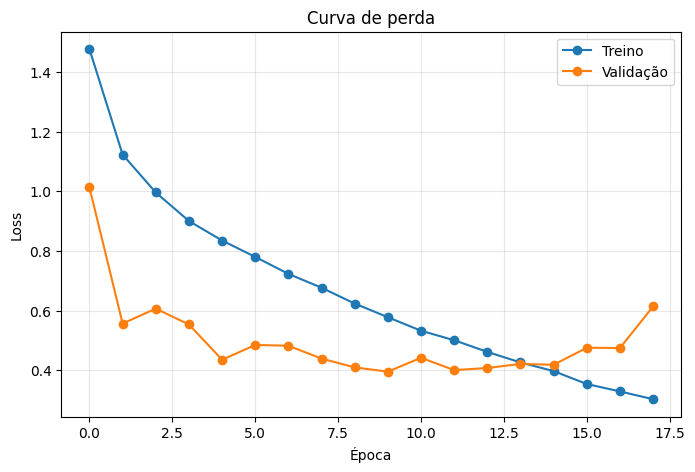

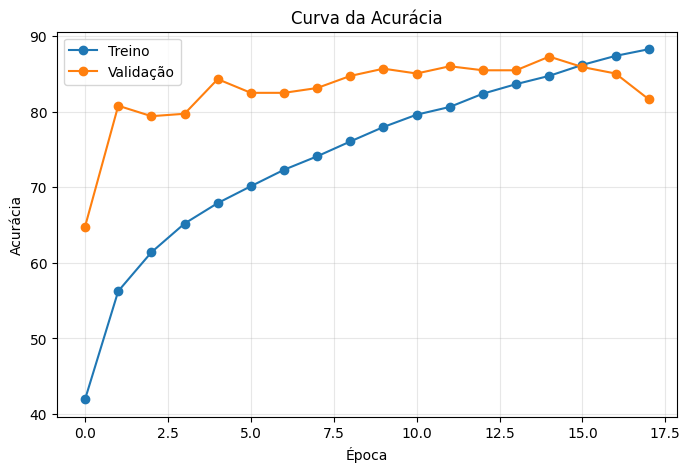

In [30]:
historico_fr = pd.DataFrame(historico)

# Plotagem do gráfico de perda do treino e validação
plt.figure(figsize=(8, 5))
plt.plot(historico_fr["epoca"], historico_fr["perdas_treino"], marker="o", label="Treino")
plt.plot(historico_fr["epoca"], historico_fr["perdas_teste"], marker="o", label="Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de perda")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("curva_perda.png", dpi=300, bbox_inches="tight")
plt.show()

# Plotagem do gráfico de acurácia do treino e validação
plt.figure(figsize=(8, 5))
plt.plot(historico_fr["epoca"], historico_fr["acuracia_treino"], marker="o", label="Treino")
plt.plot(historico_fr["epoca"], historico_fr["acuracia_teste"], marker="o", label="Validação")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Curva da Acurácia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("curva_acuracia.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
#NESTA CÉLULA OCORRE O TESTE DO MODELO

# Coloca o modelo em modo de avaliação (desativa o Dropout, altera comportamento de BatchNorm, etc)
modelo.eval()

y_true = []
y_pred = []

# torch.no_grad() desliga o cálculo de gradientes.
# Como não estamos treinando, isso economiza muita memória e deixa o processo mais rápido.
with torch.no_grad():
    for imagens, rotulos in testLoader:
        imagens, rotulos = imagens.to(device), rotulos.to(device)

        # Passa as imagens do teste pelo modelo
        saidas = modelo(imagens)

        # A saída é um tensor com 10 probabilidades. Pegamos a posição (índice) do maior valor.
        _, predicoes = torch.max(saidas.data, 1)

        y_true.extend(rotulos.cpu().numpy())
        y_pred.extend(predicoes.cpu().numpy())

#Calcula as métricas como precisão, recall e f1-score (macro avg)
metricas = classification_report(y_true, y_pred, digits=4)

print(f'Acurácia do modelo nas {total_imagens} imagens de teste: {acuracia_teste:.2f}%')
print(f'Perda do modelo nas {total_imagens} imagens de validação: {perdas_teste:.2f}%')
print(metricas)

Acurácia do modelo nas 938 imagens de teste: 81.66%
Perda do modelo nas 938 imagens de validação: 0.61%
              precision    recall  f1-score   support

           0     0.7115    0.7969    0.7518       783
           1     0.7769    0.8635    0.8179       879
           2     0.6367    0.6216    0.6291       888
           3     0.9245    0.8896    0.9067       661
           4     0.6631    0.7005    0.6813       888
           5     0.9177    0.7245    0.8098       893
           6     0.9911    0.9811    0.9861       794

    accuracy                         0.7900      5786
   macro avg     0.8031    0.7968    0.7975      5786
weighted avg     0.7971    0.7900    0.7910      5786



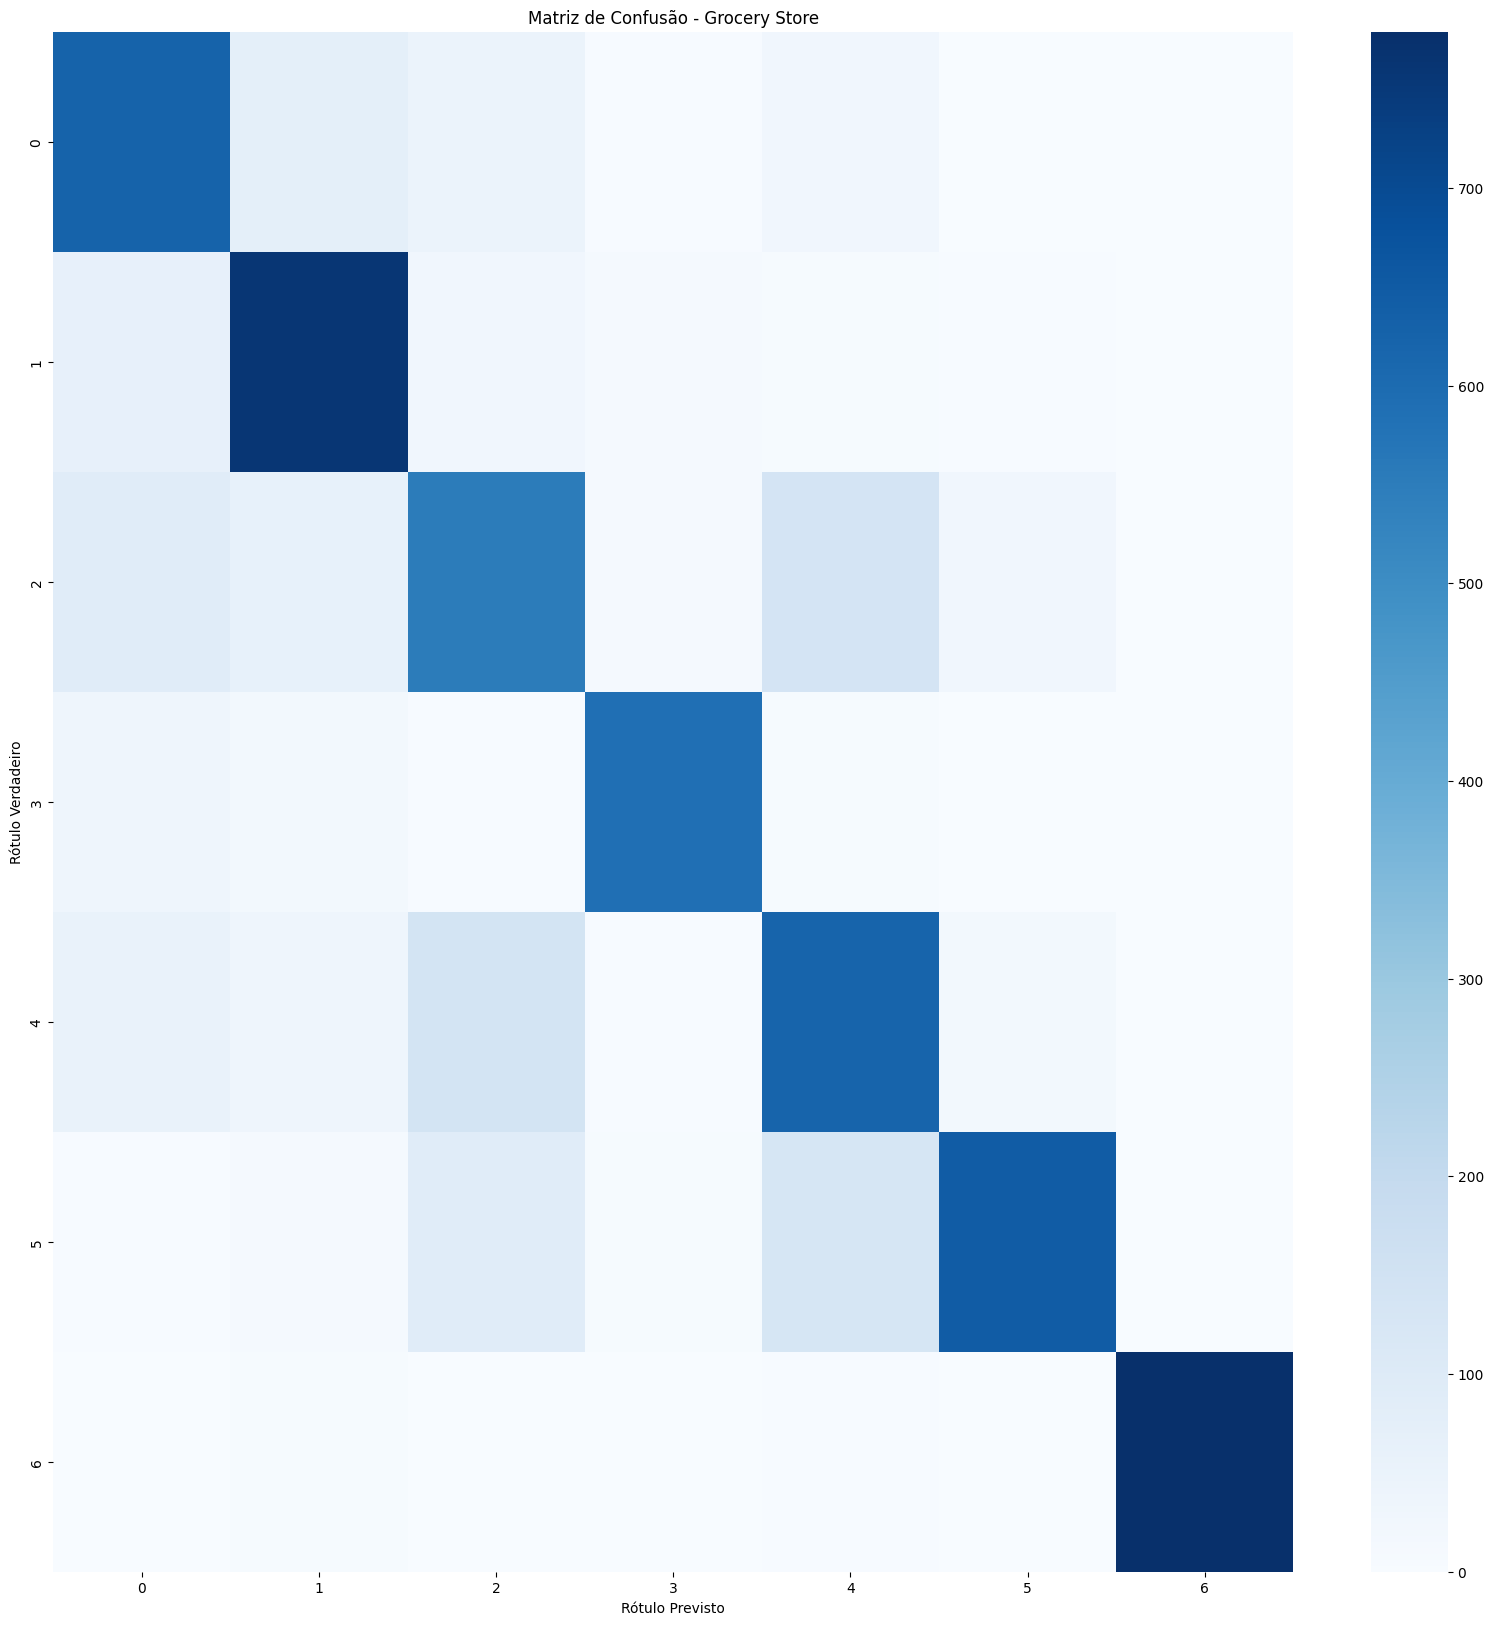

In [25]:
import seaborn as sns
import numpy as np

# Gera a matriz
cm = confusion_matrix(y_true, y_pred)

# Plota a matriz de confusão
plt.figure(figsize=(20, 20))
sns.heatmap(cm, cmap='Blues')
plt.title('Matriz de Confusão - Grocery Store')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Verdadeiro')
plt.savefig('matriz_confusao.png', bbox_inches='tight', dpi=300)
plt.show()